In [3]:
import sys
import os
import torch
import torchvision.transforms as transforms

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:    
    sys.path.append(project_root)
from src.my_app.core.MyDataset.OldMyDataset_speed import PreTrainDataset_old
from src.my_app.core.MyDataset import PreTrainDataset_v2
import multiprocessing as mp

In [4]:
# --- Dataset ---
transform = transforms.Compose([
    # transforms.Resizeze((128, 128)),
    transforms.ToTensor()
])
test_doc_id_list = ['100241706', '100249371', '100249376', '100249416', '100249476', '100249537', '200003076', '200003803', '200003967', '200004107']

train_dataset = dataset = PreTrainDataset_old(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=False,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)

test_dataset = PreTrainDataset_old(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=True,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)


# # 最適化されたDataLoaderの作成
train_dl = PreTrainDataset_old.create_optimized_dataloader_for_old_dataset(
    train_dataset,
    batch_size=1,
    num_workers=min(mp.cpu_count(), 4)
)
# test_dl = PreTrainDataset_old.create_optimized_dataloader_for_old_dataset(
#     test_dataset,
#     batch_size=1,
#     num_workers=min(mp.cpu_count(), 4)
# )

before loadGT 69
json データを読み込みました。
after loadGT 69
before loadGT 0
json データを読み込みました。
after loadGT 0


In [26]:
import numpy as np
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import label
from scipy import ndimage as ndi

def get_watershed_image(target_image):
    '''
    ウォータシェッドアルゴリズムによるセグメンテーションしたラベルマップを返す。
    - input -
    target_image: (H, W) の2次元画像テンソル
    - output -
    labels_ws: (H, W) のラベルマップ
    ピクセルの要素がラベルのIDを表している。0は背景。
    '''

    # arr: (H, W) の2値画像
    arr = target_image.cpu().numpy()
    distance = ndi.distance_transform_edt(arr > 0)

    # 局所最大値の座標リストを取得
    coordinates = peak_local_max(distance, labels=(arr > 0), footprint=np.ones((3, 3)))

    # マーカー画像を作成
    markers = np.zeros_like(distance, dtype=np.int32)
    for i, (y, x) in enumerate(coordinates, 1):
        markers[y, x] = i

    # ウォーターシェッド
    labels_ws = watershed(-distance, markers, mask=(arr > 0))
    return labels_ws

def show_watershed_image(target_image):
    '''
    ウォータシェッドアルゴリズムによるセグメンテーションしたラベルマップを返す。元画像と出力を並べて表示する。
    - input -
    target_image: (H, W) の2次元画像テンソル
    - output -
    labels_ws: (H, W) のラベルマップ
    ピクセルの要素がラベルのIDを表している。0は背景。
    '''
    labels_ws = get_watershed_image(target_image)
    import matplotlib.pyplot as plt
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(target_image.cpu().numpy())
    plt.subplot(1,2,2)
    plt.imshow(labels_ws, cmap='nipy_spectral')
    plt.title("Watershed result")
    plt.show()
    return labels_ws

def show_watershed_combined_image(target_image):
    '''
    ウォータシェッドアルゴリズムによるセグメンテーションしたラベルマップを返す。元画像と出力を重ねて表示する。
    - input -
    target_image: (H, W) の2次元画像テンソル
    - output -
    labels_ws: (H, W) のラベルマップ
    ピクセルの要素がラベルのIDを表している。0は背景。
    '''
    labels_ws = get_watershed_image(target_image)
    combined_image = (target_image.cpu().numpy() / 2) + (labels_ws / 1000)
    plt.imshow(combined_image, cmap='nipy_spectral')
    plt.title("Combined Image")
    plt.show()
    return labels_ws

def show_combine_image(image_A, image_B, show_flag=True):
    combined_image = (image_A / 2) + (image_B / 2)
    if show_flag:
        plt.imshow(combined_image, cmap='nipy_spectral')
        plt.show()
    return combined_image

tmp_tar_image.shape 

torch.Size([434, 300])

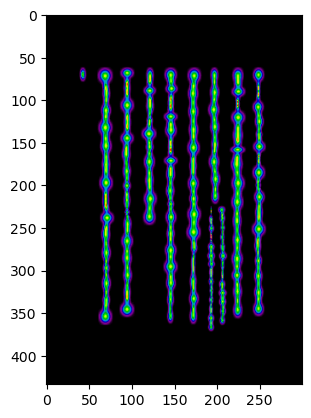

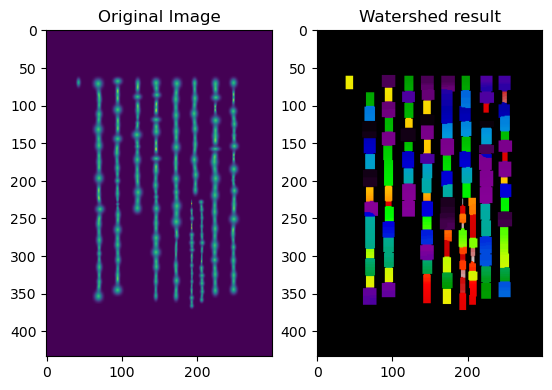

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(434, 300), dtype=int32)

In [ ]:
combined_image = show_combine_image(train_dataset[0][1][0], train_dataset[0][1][1])

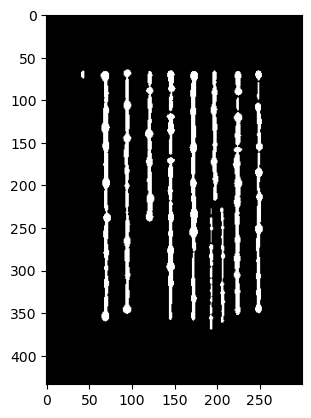

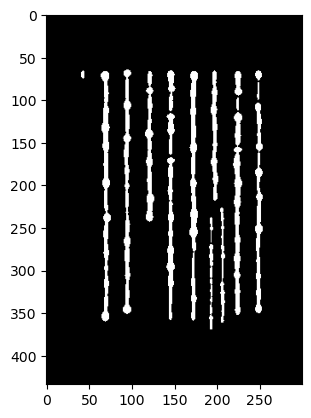

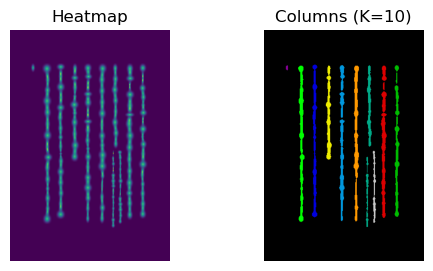

In [ ]:
# 必要なら: !pip install opencv-python
import numpy as np
import cv2
import matplotlib.pyplot as plt

def cluster_vertical_columns(
    heatmap: np.ndarray,
    thresh: float = None,
    vertical_len: int = 30,
    min_area: int = 20,
    connectivity: int = 4,
    use_otsu_fallback: bool = True
):
    """
    heatmap: (H,W) 0~1 or 任意スケールの浮動小数/uint8
    thresh: 二値化閾値 (Noneで自動). 小さくすると“緩く”繋がる
    vertical_len: 縦方向構造要素サイズ (列内の最大ギャップ+α)
    min_area: 小ノイズ除去閾値 (ピクセル数)
    return:
      labels_refined: (H,W) int32 (0=背景, 1..K=列ID)
    """
    img = heatmap.astype(np.float32)
    # 正規化 (0~255 uint8へ)
    if img.max() > 0:
        img_norm = (img / img.max())
    else:
        img_norm = img
    u8 = (img_norm * 255).clip(0,255).astype(np.uint8)

    # 1) 閾値
    if thresh is None:
        # Otsu or fallback
        if use_otsu_fallback:
            _, bin_img = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            # 線が細すぎて Otsu が高すぎる場合救済: 画素率が低いなら少し下げる
            if (bin_img > 0).mean() < 0.002:
                t2 = int(_.item() * 0.6)
                _, bin_img = cv2.threshold(u8, t2, 255, cv2.THRESH_BINARY)
        else:
            # 固定比率 (上位 70% 強度）
            t = np.quantile(u8, 0.3)
            _, bin_img = cv2.threshold(u8, t, 255, cv2.THRESH_BINARY)
    else:
        _, bin_img = cv2.threshold(u8, int(thresh*255) if thresh <= 1 else int(thresh), 255, cv2.THRESH_BINARY)
    plt.imshow(bin_img, cmap='gray')
    plt.show()


    # # 2) 小領域除去
    # num_cc, cc_labels = cv2.connectedComponents(bin_img, connectivity)
    # if num_cc > 1:
    #     counts = np.bincount(cc_labels.ravel())
    #     remove_ids = np.where(counts < min_area)[0]
    #     if len(remove_ids):
    #         mask_remove = np.isin(cc_labels, remove_ids)
    #         bin_img[mask_remove] = 0
    plt.imshow(bin_img, cmap='gray')
    plt.show()

    # 3) 縦方向モルフォロジ (列のギャップ埋め)
    kernel = np.ones((vertical_len, 1), np.uint8)
    dil = cv2.dilate(bin_img, kernel, iterations=1)
    # (必要なら細線化したければここで細らせるがまずはそのまま)

    # 4) 連結成分
    n_labels, labels = cv2.connectedComponents(dil, connectivity)

    # 5) 元の細線形状へ戻したい場合は bin_img をマスク
    labels_refined = np.zeros_like(labels, dtype=np.int32)
    fg = bin_img > 0
    labels_refined[fg] = labels[fg]

    # 6) 再連番
    used = np.unique(labels_refined)
    used = used[used != 0]
    remap = {old:i+1 for i, old in enumerate(used)}
    for old, new in remap.items():
        labels_refined[labels_refined == old] = new

    return labels_refined

def visualize_column_clusters(heatmap, labels):
    # ラベル境界を簡易表示
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap='viridis')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title(f"Columns (K={labels.max()})")
    plt.imshow(labels, cmap='nipy_spectral')
    plt.axis('off')
    plt.show()

# 使用例 (train_dataset の GT 1チャネルを想定)
tmp = combined_image.cpu().numpy()
labels = cluster_vertical_columns(tmp, thresh=None, vertical_len=40, min_area=15)
visualize_column_clusters(tmp, labels)